In [1]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split
import torchvision

In [2]:
torch.cuda.is_available()

True

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
DEVICE

device(type='cuda')

In [5]:
IMAGE_DIR = "/mnt/d/Computer-Vision/SSD-YOLO/SSD/dataset/images"
ANNOTATIONS_DIR = '/mnt/d/Computer-Vision/SSD-YOLO/SSD/dataset/annotations'
TARGET_SIZE = (300, 300)
BATCH_SIZE = 32

# Load Dataset

In [6]:
class_names = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

In [7]:
class_names

['airplane', 'face', 'motorcycle']

In [8]:
csv_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]

In [9]:
csv_files

['airplane.csv', 'face.csv', 'motorcycle.csv']

In [10]:
label_map = {name: i + 1 for i, name in enumerate(class_names)}

In [11]:
label_map

{'airplane': 1, 'face': 2, 'motorcycle': 3}

In [12]:
dataset = []

for i in range(len(class_names)):
    class_name = class_names[i]
    class_dir = os.path.join(IMAGE_DIR, class_name)
    csv_file_name = csv_files[i]
    
    csv_path = os.path.join(ANNOTATIONS_DIR, csv_file_name)
    df_annotations = pd.read_csv(csv_path)

    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape
        
        ann = df_annotations[df_annotations['image_name'] == image_name].iloc[0,1:].tolist()

        if (ann[2] > ann[0] and ann[3] > ann[1]):
            ann[0] = int((ann[0] / w) * 300)
            ann[1] = int((ann[1] / h) * 300)
            ann[2] = int((ann[2] / w) * 300)
            ann[3] = int((ann[3] / h) * 300)
            
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_resized = cv2.resize(image, TARGET_SIZE)
            
            image_tensor = torch.tensor(image_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0
            
            class_id = label_map[class_name]
            labels_tensor = torch.tensor([class_id], dtype=torch.int64)
            ann_tensor = torch.tensor([ann], dtype=torch.float32)
    
            target = {
                'boxes': ann_tensor,
                'labels': labels_tensor
            }
            dataset.append((image_tensor, target))
        else:
            print(f"️Invalid box found and removed in '{image_path}': {ann}")

def collate_fn(batch):
    return tuple(zip(*batch))

️Invalid box found and removed in '/mnt/d/Computer-Vision/SSD-YOLO/SSD/dataset/images/airplane/image_0118.jpg': [np.int64(104), np.int64(38), np.int64(126), np.int64(38)]


# Train_Test_Split

In [13]:
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

In [14]:
generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)

In [15]:
print(f"Dataset ({len(dataset)})")

Dataset (2032)


In [16]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train ({len(train_dataset)}), Test ({len(test_dataset)})")

Train (1828), Test (204)


# Modeling

In [20]:
model = torchvision.models.detection.ssd300_vgg16(
    weights=torchvision.models.detection.SSD300_VGG16_Weights.DEFAULT,
)

Changing head for producing same num predicts with num of class in this issue.

In [27]:
in_channels = []
for i in range(len(model.head.classification_head.module_list)):
    in_channels.append(model.head.classification_head.module_list[i].in_channels)

In [28]:
in_channels

[512, 1024, 512, 256, 256, 256]

In [29]:
num_anchors = model.anchor_generator.num_anchors_per_location()

In [30]:
num_anchors

[4, 6, 6, 6, 4, 4]

In [31]:
num_classes = len(label_map) + 1

In [32]:
model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

In [33]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)

In [34]:
epochs = 5
model.to(DEVICE)
model.train()

for epoch in range(epochs):
    train_loss = 0.0
    # ---- Train ----
    for images, targets in train_loader:
        optimizer.zero_grad()
        
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
        loss_dict_train = model(images, targets)
        loss = sum(l for l in loss_dict_train.values())
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()

     # ---- Validation ----
    test_loss = 0.0
    with torch.no_grad():
        for images, targets in test_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
            loss_dict_test = model(images, targets)
            loss = sum(l for l in loss_dict_test.values())
            test_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss = test_loss / len(test_loader)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_test_loss:.4f}")

Epoch 1/5 | Train Loss: 5.2130 | Val Loss: 2.4060
Epoch 2/5 | Train Loss: 1.3884 | Val Loss: 1.0097
Epoch 3/5 | Train Loss: 0.8186 | Val Loss: 0.7240
Epoch 4/5 | Train Loss: 0.6241 | Val Loss: 0.6454
Epoch 5/5 | Train Loss: 0.5281 | Val Loss: 0.5426


# Calculate mAP

In [35]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [36]:
def calculate_map(model, dataloader, device):
    metric = MeanAveragePrecision(box_format='xyxy')
    
    model.eval()
    model.to(device)
    
    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            predictions = model(images)
            
            metric.update(predictions, targets)
            
    results = metric.compute()
    

    print(f"mAP: {results['map'].item():.4f}")
    print(f"mAP@50 (IoU=0.50): {results['map_50'].item():.4f}")
    print(f"mAP@75 (IoU=0.75): {results['map_75'].item():.4f}")

    return results

In [37]:
test_map_results = calculate_map(model, test_loader, DEVICE)

/home/ramin/gpu-pytorch/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


mAP: 0.8376
mAP@50 (IoU=0.50): 1.0000
mAP@75 (IoU=0.75): 1.0000


In [38]:
train_map_results = calculate_map(model, train_loader, DEVICE)

mAP: 0.8614
mAP@50 (IoU=0.50): 0.9967
mAP@75 (IoU=0.75): 0.9895


In [39]:
def predict_on_image_single_object(model, image_path, device, label_map):

    original_image = cv2.imread(image_path)
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    
    image_for_model = cv2.resize(original_image_rgb, TARGET_SIZE)
    image_tensor = (torch.tensor(image_for_model, dtype=torch.float32).permute(2, 0, 1) / 255.0).unsqueeze(0)
    
    model.eval()
    model.to(device)

    with torch.no_grad():
        prediction = model(image_tensor.to(device))[0]
        
    if len(prediction['scores']) == 0:
        print("No object")
        return

    best_score_idx = torch.argmax(prediction['scores']).item()
    score = prediction['scores'][best_score_idx].cpu().item()
    box = prediction['boxes'][best_score_idx].cpu().numpy()
    label_id = prediction['labels'][best_score_idx].cpu().item()


    reverse_label_map = {v: k for k, v in label_map.items()}
    label_name = reverse_label_map.get(label_id, 'Unknown')

    h_orig, w_orig, _ = original_image.shape
    x_scale = w_orig / TARGET_SIZE[0]
    y_scale = h_orig / TARGET_SIZE[1]
    
    xmin = int(box[0] * x_scale)
    ymin = int(box[1] * y_scale)
    xmax = int(box[2] * x_scale)
    ymax = int(box[3] * y_scale)
    
    cv2.rectangle(original_image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3) 
    cv2.putText(original_image, f"{label_name}: {score:.2f}", (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

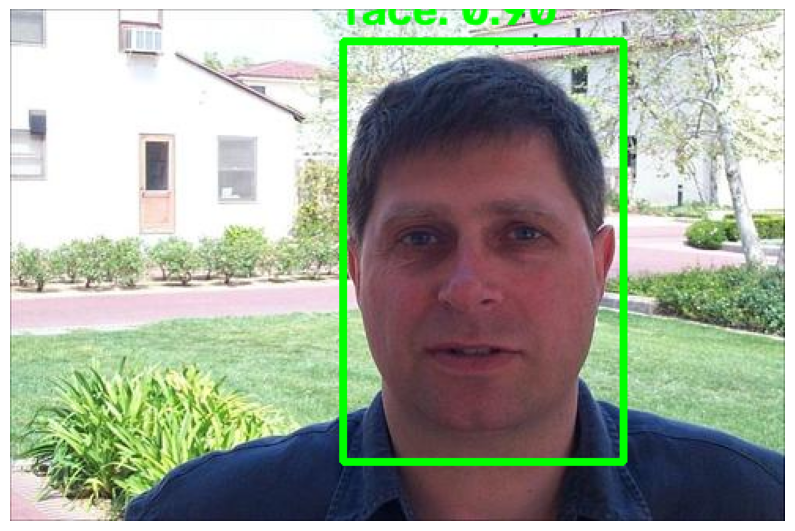

In [41]:
image_path_to_predict = "dataset/images/face/image_0003.jpg"
predict_on_image_single_object(model, image_path_to_predict, DEVICE, label_map)